#### Sales Forecasting Project
#### Predicting Weekly Store Sales using Machine Learning

### Problem Statement
- Sales forecasting means predicting future sales using previous sales data.
- This helps businesses in:
-- inventory management
-- business planning
-- budgeting
-- understanding customer demand
- In this project, we will analyze Walmart sales data and build a Machine Learning model to predict weekly sales.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#pandas: handling dataset
#numpy: numerical operations
#matplotlib: basic graphs
#seaborn: attractive visualizations

### Load Dataset Files

In [2]:
#The Walmart dataset contains:
#train file → training sales data
#test file → testing data
#features file → external factors
#stores file → store details

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")

In [3]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [4]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05-02-2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12-02-2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19-02-2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26-02-2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05-03-2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [5]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [6]:
train.info()

#.info() gives:
#number of rows and columns
#data types
#missing values
#This helps in preprocessing.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [7]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [8]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [9]:
## Convert Date Columns
# Machine Learning cannot understand dates directly.
# So we convert Date columns into datetime format.
# This also helps during merging
train['Date'] = pd.to_datetime(train['Date'],
                               format='mixed',
                               dayfirst=True)

test['Date'] = pd.to_datetime(test['Date'],
                              format='mixed',
                              dayfirst=True)

features['Date'] = pd.to_datetime(features['Date'],
                                  format='mixed',
                                  dayfirst=True)

## Merge Datasets
- The Walmart data is divided into different files:
- train → sales data
- features → temperature, fuel price, CPI etc.
- stores → store type and size
- We merge all datasets into one final dataset using common columns.
- This creates a complete dataset for analysis and prediction.

In [10]:
#### STEP 1: Merge train + features
## Common columns:
# Store
# Date
# IsHoliday
df = pd.merge(train,
              features,
              on=['Store', 'Date', 'IsHoliday'],
              how='left')
# how = 'left' -> It keeps all rows from train dataset and adds matching data from features dataset.

In [11]:
#### STEP 2: Merge stores data
## Common column:
# Store
df = pd.merge(df,
              stores,
              on='Store',
              how='left')

In [12]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [13]:
df.shape

(421570, 16)

### Data Cleaning : means fixing:
- missing values
- incorrect data types
- duplicate records
- Clean data improves model accuracy and performance.

#### Step 1: Check Missing Values : 
- Missing values (NaN) are empty entries in the dataset. Machine Learning models cannot handle them properly, so we clean them.

In [14]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64

### Step 2: Handle Missing Values
- MarkDown columns represent promotional discounts.
- Missing values mean:
- “No markdown/discount available.”
- So replacing them with 0 is the correct approach.

In [15]:
markdown_cols = ['MarkDown1',
                 'MarkDown2',
                 'MarkDown3',
                 'MarkDown4',
                 'MarkDown5']

df[markdown_cols] = df[markdown_cols].fillna(0)

In [16]:
df.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64

### Step 3: Check Duplicate Rows
- Duplicate rows are repeated records in the dataset.
- They may affect model performance.

In [17]:
df.duplicated().sum()

np.int64(0)

### Feature Engineering
- Feature engineering means creating new useful columns from existing data.
- From the Date column, we extract:
-- Year
-- Month
-- Week
- This helps the model understand:
-- seasonal trends
-- monthly patterns
-- yearly changes in sales

In [18]:
df['Year'] = df['Date'].dt.year  ## extract date

In [19]:
df['Month'] = df['Date'].dt.month  ## extract month

In [20]:
df['Week'] = df['Date'].dt.isocalendar().week   ## extract week

In [21]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,2010,2,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,2010,2,6
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,2010,2,7
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,2010,2,8
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,2010,3,9


### Encode Categorical Data
- Machine Learning models work with numbers, not text values.
- The Type column contains:
-- A, B, C
- So we convert it into numerical format.
- This process is called: Encoding

In [22]:
df = pd.get_dummies(df,
                    columns=['Type'],
                    drop_first=True)

## drop_first=TRue -> If categories are: A, B, C
# Then pandas creates: Type_B Type_C : This avoids duplicate information.

In [23]:
df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Year', 'Month', 'Week',
       'Type_B', 'Type_C'],
      dtype='object')

### Exploratory Data Analysis (EDA)
- EDA means analyzing data using graphs and visualizations.
- It helps us understand:
-- sales trends
-- seasonal patterns
-- holiday impact
-- relationships between variables
- EDA makes the project more impactful and easier to explain

## Graph 1: Sales Trend Over Time
- This graph shows how weekly sales change over time.
- It helps identify:
- increasing/decreasing trends
- seasonal fluctuations
- sales spikes

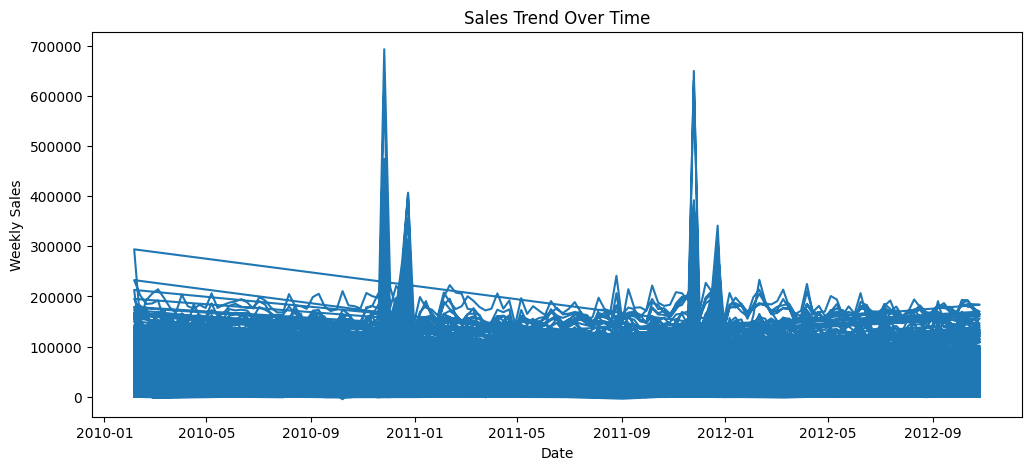

In [24]:
plt.figure(figsize=(12,5))

plt.plot(df['Date'],
         df['Weekly_Sales'])

plt.title("Sales Trend Over Time")

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.show()

## Graph 2: Monthly Sales Analysis
- This graph compares sales across different months.
- It helps identify:
- high sales months
- low sales months
- seasonal business patterns

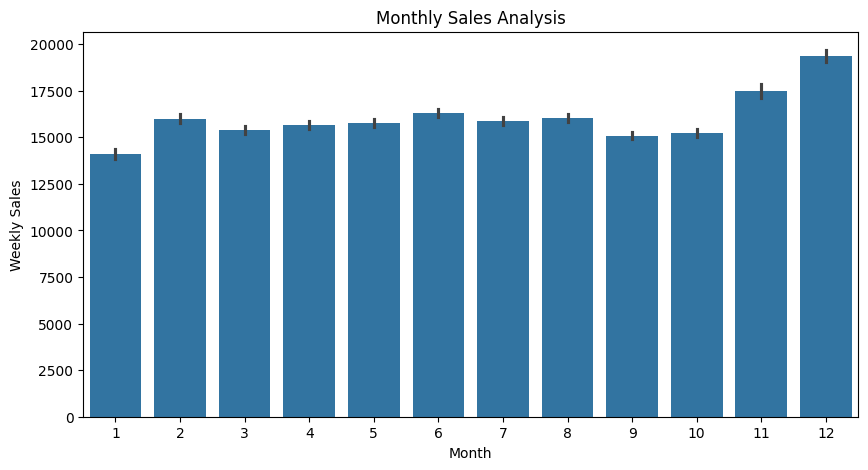

In [25]:
plt.figure(figsize=(10,5))

sns.barplot(x='Month',
            y='Weekly_Sales',
            data=df)

plt.title("Monthly Sales Analysis")

plt.xlabel("Month")

plt.ylabel("Weekly Sales")

plt.show()

## Graph 3: Holiday vs Non-Holiday Sales
- This graph compares sales during:
- holiday weeks
- non-holiday weeks

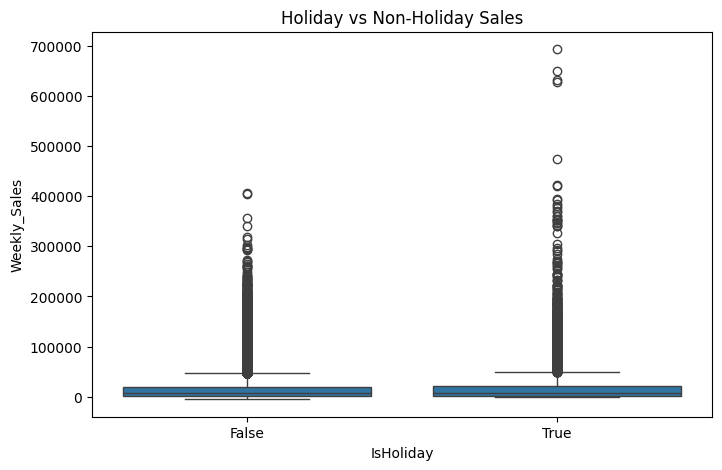

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x='IsHoliday',
            y='Weekly_Sales',
            data=df)

plt.title("Holiday vs Non-Holiday Sales")

plt.show()

## Graph 4: Correlation Heatmap
- A heatmap shows relationships between numerical variables.
- It helps identify:
- strongly related features
- positively/negatively correlated variables

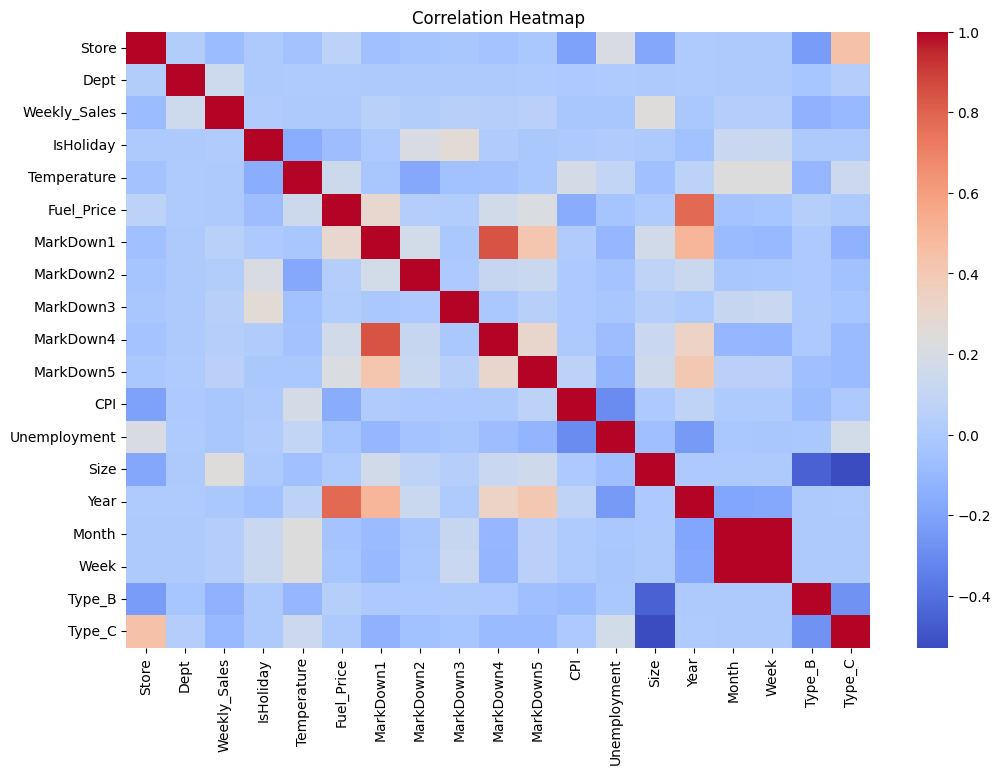

In [27]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

### Prepare Data for Model
- We separate: input features (X) , target variable (y)
- Target variable: Weekly_Sales
- because this is what we want to predict.

In [28]:
X = df.drop(['Weekly_Sales', 'Date'],
            axis=1)

y = df['Weekly_Sales']

### Train-Test Split
- We divide data into:
- training data → model learns
- testing data → model evaluation

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Model Building
- We use: Random Forest Regressor : because:
-- good accuracy
-- handles large datasets well
-- beginner friendly

In [32]:
df_sample = df.sample(50000, random_state=42)

In [33]:
X = df_sample.drop(['Weekly_Sales', 'Date'],
                   axis=1)

y = df_sample['Weekly_Sales']

### Prediction
- Now the trained model predicts weekly sales.

In [34]:
y_pred = model.predict(X_test)

### Model Evaluation
- We evaluate model performance using:
- MAE → prediction error
- R² Score → accuracy

In [35]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)

print("R2 Score:", r2)

MAE: 1454.0636722940437
R2 Score: 0.9733595980658518


### Actual vs Predicted Graph


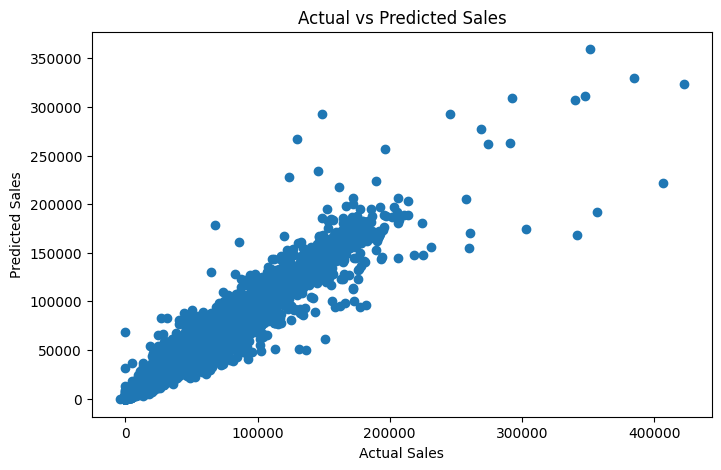

In [36]:
plt.figure(figsize=(8,5))

plt.scatter(y_test,
            y_pred)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()